## Phase 2 Project - Group 5

### Business Understanding

#### Overview/Background
- We are a new content creation company that want to set up a movie studio to start making original content in the form of film (movies, documentaries,etc) 

- Our decision is spurred by observing trends in big media conglomerates diversifying their offerings from public broadcasting (news, documentaries) into original content in the form of long and short form films. 

#### Challenges
- We currently have a gap in our understanding of the current movie landscape from the demand side and want our analysis to answer the simple question: what kind of movies are most people watching? 

#### Proposed Solution
- To answer this question, we will carry out **a comprehensive market analysis**, using data sourced from popular movie rating databases as well as revenue data describing the financial performance of movies.

- Our core business metric would be **gross movie revenue** across movie genres in both domestic and foreign markets, i.e., what kind of movies have made the most money? 

- This analysis will not only guide our content generation strategy but also our business strategy as to which market to focus on.


#### Key Objectives
- Our analysis will be guided by the following key business objectives:

    1. To determine the most popular movie genres based on movie ratings and revenues

    2. To determine the best movie directors based on movie ratings and revenues
    
    3. To determine the most profitable movie markets based on movie revenues


## DATA UNDERSTANDING
### 1.Film Titles & Genres:
#### The dataset contains a variety of film titles along with their genres (e.g., Action, Drama, Comedy).
#### Certain genres may consistently perform better at the box office.
### 2. Box Office Performance:
#### Box Office Mojo provides domestic and worldwide gross earnings.
#### This financial data helps identify the types of movies that bring the highest returns.


### 3. Ratings & Viewer Feedback:
#### IMDB and Rotten Tomatoes offer user ratings, critic scores, and audience reception.
#### Highly-rated films may indicate preferred content types or production quality.


### 4. Release Year & Trends:
#### Films are tagged with their release year, allowing for trend analysis over time.
#### Helps determine if recent years favor specific film styles or formats.


### 5. Multi-Source Data Integration:
#### By combining IMDB (content), Box Office Mojo (revenue), and Rotten Tomatoes (ratings),
#### we can form a well-rounded view of what makes a film both critically and financially successful.




## DATA PREPARATION

#### Importing Relevant Libraries

- We start by importing the following libraries: **NumPy**, **Pandas**, **SQLite**, **Matplotlib** and **Seaborn**

In [1]:
# importing necessary libraries
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
print([f for f in os.listdir() if f.startswith('matplotlib')])

- We then open up a connection to the SQLite database and store the connection in a variable called `conn`. Afterwards, we initialize a SQLite cursor object with the variable name `cursor`.

In [2]:
# read our sqlite database and create a variable df to hold the database
df = "./zippedData/im.db/im.db"

# Open up a connection
conn = sqlite3.connect(df)

# Initialize a cursor
cursor = conn.cursor()

OperationalError: unable to open database file

### Data Ingest
- We are going to extract data from two key sources: the SQL database and CSV files.


#### Extracting tables from SQL database 

- We will use `pd.read_sql` to output the tables in the SQLite database via SQL queries 

- When writing our queries, we will use the table names as listed below:

In [ ]:

table_names = """SELECT name 
                      AS 'Table Names' 
                      FROM sqlite_master 
                      WHERE type='table';"""

pd.read_sql(table_names, conn)

,Table Names
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


- We define the SQL queries we will use to extract the relevant tables from our dataset and then apply `pd.read_sql` to output our tables as dataframes

- Our tables of interest include: `movie_basics`, `movie_akas`, `movie_ratings`, `directors` and `persons`


In [ ]:
movie_basics_query = """SELECT * FROM movie_basics;"""
movie_basics_df = pd.read_sql(movie_basics_query, conn)

movie_ratings_query = """SELECT * FROM movie_ratings;"""
movie_ratings_df = pd.read_sql(movie_ratings_query, conn)

movie_akas_query = """SELECT * FROM movie_akas;""" 
movie_akas_df = pd.read_sql(movie_akas_query, conn)

directors_query = """SELECT * FROM directors;"""
directors_df = pd.read_sql(directors_query, conn)

persons_query = """SELECT * FROM persons;"""
persons_df = pd.read_sql(persons_query, conn)

- The dataset on movie revenue exists as a `csv` file so we extract it and save it as Dataframe as well:

In [ ]:
movie_budgets_df = pd.read_csv("./zippedData/tn.movie_budgets.csv.gz")

movie_budgets_df.rename(columns={"movie": "title"}, inplace=True)


#### Inspecting our Dataframes

- We quickly inspect the resulting dataframes:

In [ ]:
movie_basics_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [ ]:
movie_ratings_df.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [ ]:
movie_akas_df.head()

,movie_id,ordering,title,region,language,types,attributes,is_original_title
0,tt0369610,10,Джурасик свят,BG,bg,None,None,0.0
1,tt0369610,11,Jurashikku warudo,JP,None,imdbDisplay,None,0.0
2,tt0369610,12,Jurassic World: O Mundo dos Dinossauros,BR,None,imdbDisplay,None,0.0
3,tt0369610,13,O Mundo dos Dinossauros,BR,None,None,short title,0.0
4,tt0369610,14,Jurassic World,FR,None,imdbDisplay,None,0.0


In [ ]:
movie_budgets_df.head()

,id,release_date,title,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [ ]:
directors_df.head()

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502


In [ ]:
persons_df.head()

,person_id,primary_name,birth_year,death_year,primary_profession
0,nm0061671,Mary Ellen Bauder,NaN,NaN,"miscellaneous,production_manager,producer"
1,nm0061865,Joseph Bauer,NaN,NaN,"composer,music_department,sound_department"
2,nm0062070,Bruce Baum,NaN,NaN,"miscellaneous,actor,writer"
3,nm0062195,Axel Baumann,NaN,NaN,"camera_department,cinematographer,art_department"
4,nm0062798,Pete Baxter,NaN,NaN,"production_designer,art_department,set_decorator"


### Data Cleaning
- We shall identify columns or rows in the tables with missing or duplicate values.

- Then we either fill in missing values or remove records that are too incomplete or records that are duplicated.

##### Check for missing values

In [ ]:
# Checking all the tables for null values
print("-" * 60)
print("Movie Basics Null Values:", '\n')
print(movie_basics_df.isnull().sum())
print("-" * 60)
print("Movie Ratings Null Values:", '\n') 
print(movie_ratings_df.isnull().sum())
print("-" * 60)
print("Movie Akas Null Values:", '\n')
print(movie_akas_df.isnull().sum())
print("-" * 60)
print("Movie Budgets Null Values:", '\n')
print(movie_budgets_df.isnull().sum())
print("-" * 60)
print("Directors Null Values:", '\n')
print(directors_df.isnull().sum())
print("-" * 60)
print("Persons Null Values:", '\n')
print(persons_df.isnull().sum())
print("-" * 60)

------------------------------------------------------------
Movie Basics Null Values: 

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64
------------------------------------------------------------
Movie Ratings Null Values: 

movie_id         0
averagerating    0
numvotes         0
dtype: int64
------------------------------------------------------------
Movie Akas Null Values: 

movie_id                  0
ordering                  0
title                     0
region                53293
language             289988
types                163256
attributes           316778
is_original_title        25
dtype: int64
------------------------------------------------------------
Movie Budgets Null Values: 

id                   0
release_date         0
title                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64
-----------------------

##### Handle the missing values
- We do this by either dropping the missing values or filling the columns with 'unknown'

In [ ]:
# Handling missing values

# Drop columns with more than 50% missing values in movie_akas_df
movie_akas_df = movie_akas_df.drop(columns=['language', 'attributes', 'types'])

# Drop rows with missing runtime_minutes in movie_basics_df
movie_basics_df = movie_basics_df.dropna(subset=['runtime_minutes'])


# Fill missing values in movie_akas_df
movie_akas_df['region'] = movie_akas_df['region'].fillna('Unknown')
movie_akas_df['is_original_title'] = movie_akas_df['is_original_title'].fillna(0)

# Fill missing values in persons_df
persons_df['birth_year'] = persons_df['birth_year'].fillna(0)
persons_df['death_year'] = persons_df['death_year'].fillna(0)
persons_df['primary_profession'] = persons_df['primary_profession'].fillna('Unknown')




- Recheck the updated dataframes to verify our changes:

In [ ]:
# Print the updated dataframes to verify changes
print("-" * 60)
print("Updated movie_basics_df:",'\n')
print(movie_basics_df.isnull().sum())
print("-" * 60)
print("Updated movie_ratings_df:",'\n')
print(movie_ratings_df.isnull().sum())
print("-" * 60)
print("Updated movie_budgets_df:", '\n')
print(movie_budgets_df.isnull().sum())
print("-" * 60)
print("Updated movie_akas_df:", '\n')
print(movie_akas_df.isnull().sum())
print("-" * 60)
print("Updated directors_df:", '\n')
print(directors_df.isnull().sum())
print("-" * 60)
print("Updated persons_df:", '\n')
print(persons_df.isnull().sum())
print("-" * 60)


------------------------------------------------------------
Updated movie_basics_df: 

movie_id              0
primary_title         0
original_title        4
start_year            0
runtime_minutes       0
genres             2172
dtype: int64
------------------------------------------------------------
Updated movie_ratings_df: 

movie_id         0
averagerating    0
numvotes         0
dtype: int64
------------------------------------------------------------
Updated movie_budgets_df: 

id                   0
release_date         0
title                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64
------------------------------------------------------------
Updated movie_akas_df: 

movie_id             0
ordering             0
title                0
region               0
is_original_title    0
dtype: int64
------------------------------------------------------------
Updated directors_df: 

movie_id     0
person_id    0
dtype: int64
--------------

#### Handling Duplicates

- Remove duplicates in case any exist:

In [ ]:
# Remove duplicates
movie_basics_df = movie_basics_df.drop_duplicates()
movie_ratings_df = movie_ratings_df.drop_duplicates()
movie_akas_df = movie_akas_df.drop_duplicates()
movie_budgets_df = movie_budgets_df.drop_duplicates()
directors_df = directors_df.drop_duplicates()
persons_df = persons_df.drop_duplicates()


### Save Cleaned Tables
In the cell below we have saved our cleaned dataframe into csv files for future reference.It is an optional step.

In [ ]:
# Save cleaned dataframes to CSV files
# movie_basics_df.to_csv('cleaned_movie_basics.csv', index=False)
# movie_ratings_df.to_csv('cleaned_movie_ratings.csv', index=False)
# movie_akas_df.to_csv('cleaned_movie_akas.csv', index=False)
# movie_budgets_df.to_csv('cleaned_movie_budgets.csv', index=False)
# directors_df.to_csv('cleaned_directors.csv', index=False)
# persons_df.to_csv('cleaned_persons.csv', index=False)


### Data Merging
- We will combine our 6 resulting dataframes in this fashion:

    1) Merge `movies_basics_df` with `movie_ratings` on `movie_id` and save as `movies_consolidated_df`

    2) Merge resulting `movies_consolidated_df` with `movie_akas_df` on `movie_id` and save as `movies_consolidated_df`

    3) Merge resulting `movies_consolidated_df` with `directors_df` on `movie_id` and save as `movies_consolidated_df`

    4) Merge resulting `movies_consolidated_df` with `persons_df` on `person_id` and save as `movies_consolidated_df`

    5) Merge resulting `movies_consolidated_df` with `movie_budgets_df` on `title` and save as `movies_consolidated_df`


In [ ]:
# Merge movie_basics_df with movie_ratings_df on movie_id
movies_consolidated_df = pd.merge(movie_basics_df, movie_ratings_df, on='movie_id', how='left')

# Merge the result with movie_akas_df on movie_id
movies_consolidated_df = pd.merge(movies_consolidated_df, movie_akas_df, on='movie_id', how='left')

# Merge the result with directors_df on movie_id
movies_consolidated_df = pd.merge(movies_consolidated_df, directors_df, on='movie_id', how='left')

# Merge the result with persons_df on person_id
movies_consolidated_df = pd.merge(movies_consolidated_df, persons_df, on='person_id', how='left')

# Merge the result with movie_budgets_df on title
movies_consolidated_df = pd.merge(movies_consolidated_df, movie_budgets_df, on='title', how='left')

# Drop duplicate rows based on movie_id and person_id
movies_consolidated_df = movies_consolidated_df.drop_duplicates(subset=['movie_id', 'person_id'])

# Drop rows with missing values in the merged dataframe
movies_consolidated_df = movies_consolidated_df.dropna(subset=['averagerating','numvotes','domestic_gross', 'worldwide_gross',])

# Drop unnecessary columns
irrelevant_columns = ['person_id','ordering', 'title','birth_year','death_year','id', 'is_original_title']
movies_consolidated_df = movies_consolidated_df.drop(columns=irrelevant_columns)

# Rename columns for clarity
movies_consolidated_df.rename(columns={'primary_name': 'director_name', 'primary_profession': 'director_profession'}, inplace=True)

# Fill missing values in the remaining columns
movies_consolidated_df['director_name'] = movies_consolidated_df['director_name'].fillna('Unknown')
movies_consolidated_df['director_profession'] = movies_consolidated_df['director_profession'].fillna('Unknown')

#Save the consolidated dataframe to a CSV file
movies_consolidated_df.to_csv('movies_consolidated.csv', index=False)


# Display the first few rows of the consolidated dataframe
movies_consolidated_df.head().reset_index(drop=True)




,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,region,director_name,director_profession,release_date,production_budget,domestic_gross,worldwide_gross
0,tt0249516,Foodfight!,Foodfight!,2012,91.0,"Action,Animation,Comedy",1.9,8248.0,FI,Lawrence Kasanoff,"producer,writer,director","Dec 31, 2012","$45,000,000",$0,"$73,706"
1,tt0339736,The Evil Within,The Evil Within,2017,98.0,Horror,5.6,2420.0,US,Andrew Getty,"director,writer","Oct 10, 2014","$3,300,000","$13,092,006","$38,969,037"
2,tt0393049,Anderson's Cross,Anderson's Cross,2010,98.0,"Comedy,Drama,Romance",5.5,106.0,US,Jerome Elston Scott,"actor,director,writer","Dec 31, 2010","$300,000",$0,$0
3,tt0443272,Lincoln,Lincoln,2012,150.0,"Biography,Drama,History",7.4,228701.0,HR,Steven Spielberg,"producer,writer,director","Nov 9, 2012","$65,000,000","$182,207,973","$273,346,281"
4,tt0454876,Life of Pi,Life of Pi,2012,127.0,"Adventure,Drama,Fantasy",7.9,535836.0,Unknown,Ang Lee,"director,producer,writer","Nov 21, 2012","$120,000,000","$124,987,022","$620,912,003"


In [ ]:
movies_consolidated_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1238 entries, 66 to 362808
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   movie_id             1238 non-null   object 
 1   primary_title        1238 non-null   object 
 2   original_title       1238 non-null   object 
 3   start_year           1238 non-null   int64  
 4   runtime_minutes      1238 non-null   float64
 5   genres               1238 non-null   object 
 6   averagerating        1238 non-null   float64
 7   numvotes             1238 non-null   float64
 8   region               1238 non-null   object 
 9   director_name        1238 non-null   object 
 10  director_profession  1238 non-null   object 
 11  release_date         1238 non-null   object 
 12  production_budget    1238 non-null   object 
 13  domestic_gross       1238 non-null   object 
 14  worldwide_gross      1238 non-null   object 
dtypes: float64(3), int64(1), object(11)

### Exploratory Data Analysis(EDA)

#### Distribution of movie ratings
- The 'distribution of the movie ratings' refers to how different movie ratings were given to a movie.
- In the cell below we are going to plot a histogram so as to determine our distribution.

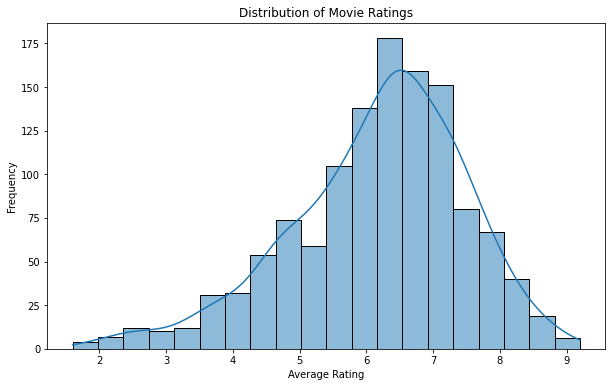

In [ ]:
# Plotting the distribution of movie ratings
plt.figure(figsize=(10, 6))
sns.histplot(movies_consolidated_df['averagerating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Checking for correlation
corr = movies_consolidated_df.corr(method='pearson')
corr.style.background_gradient(cmap='coolwarm')

Each square shows the correlation between the variables on each axis. Correlation ranges from -1 to +1. Values closer to zero means there is no linear trend between the two variables. The close to 1 the correlation is the more positively correlated they are; that is as one increases so does the other and the closer to 1 the stronger this relationship is. A correlation closer to -1 is similar, but instead of both increasing one variable will decrease as the other increases. The diagonals are all 1/red because those squares are correlating each variable to itself (so it's a perfect correlation). For the rest the larger the number and darker the color the higher the correlation between the two variables. The plot is also symmetrical about the diagonal since the same two variables are being paired together in those squares. 

#### Find the Top performing directors based on the ratings

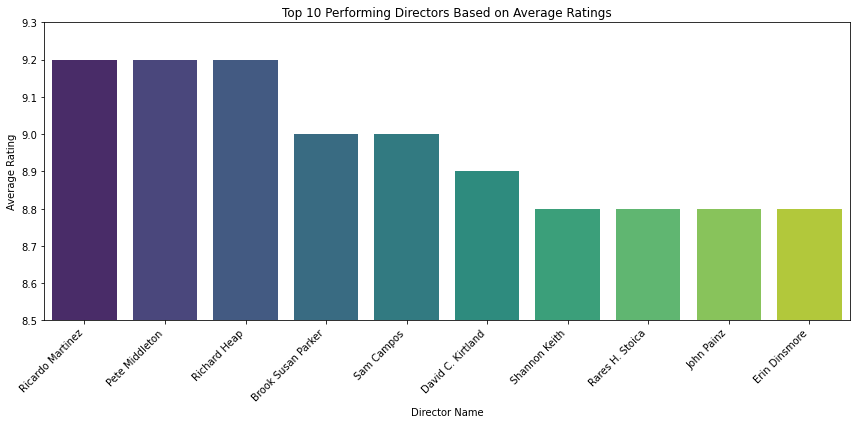

In [ ]:
# Group by 'director_name' and calculate the average rating
top_directors = movies_consolidated_df.groupby('director_name')['averagerating'].mean().reset_index()

# Sort the directors by average rating in descending order
top_directors = top_directors.sort_values(by='averagerating', ascending=False).head(10)

# Plot the graph
plt.figure(figsize=(12, 6))
sns.barplot(data=top_directors, x='director_name', y='averagerating', palette='viridis')
plt.title('Top 10 Performing Directors Based on Average Ratings')
plt.xlabel('Director Name')
plt.ylabel('Average Rating')

# Set y-axis limits to zoom into the 8.5–9.5 range
plt.ylim(8.5, 9.3)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

From the anlysis and visualization above, these are the top 10 performing movie directors based on the ratings, 'Ricardo Martinez, Pete middleton and 'Richard Heap' have the highest ratings of about 9.2

#### Finding the Top 10 rated movies

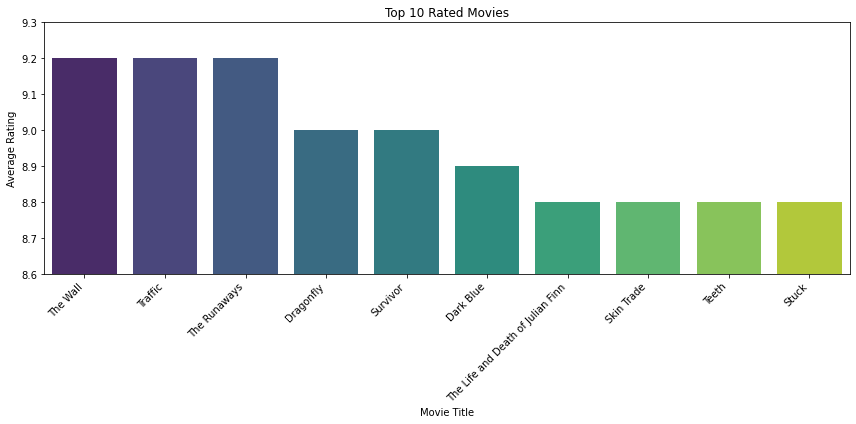

In [ ]:
# Sort the movies by averagerating in descending order and select the top 10
top_rated_movies = movies_consolidated_df.sort_values(by='averagerating', ascending=False).head(10)

# Plot the graph
plt.figure(figsize=(12, 6))
sns.barplot(data=top_rated_movies, x='primary_title', y='averagerating', palette='viridis')
plt.title('Top 10 Rated Movies')
plt.ylabel('Average Rating')
plt.xlabel('Movie Title')

# Set y-axis limits to zoom into the 8.5–9.5 range
plt.ylim(8.6, 9.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The above movies are the top 10 higest rated movies where 'The Wall', 'Traffic', and 'The Runways' are the top 3 honorable mentions

#### Find the most popular movie genres

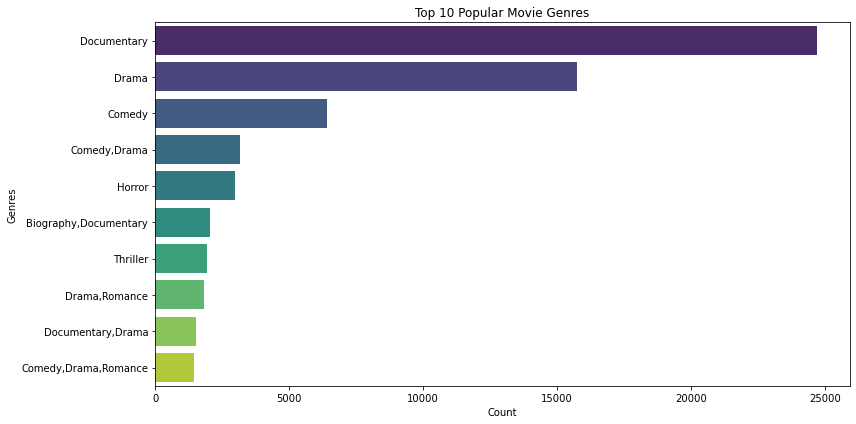

In [ ]:
# Count the occurrences of each genre in the 'genre' column of the movie_basics_df DataFrame
genre_counts = movie_basics_df['genres'].str.split('&').explode().value_counts().head(10)

# Convert the counts into a DataFrame for easier plotting
genre_counts_df = genre_counts.reset_index()
genre_counts_df.columns = ['Genres', 'Count']

# Plot the graph
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Genres', data=genre_counts_df, palette='viridis')
plt.title('Top 10 Popular Movie Genres')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.tight_layout()
plt.show()

These are the most popular movie genres across our datasets, documentaries leading the list with the most popularity.

## Top 10 most selling genres domestically

In [ ]:
# Ensure 'domestic_gross' is numeric
movies_consolidated_df['domestic_gross'] = (
    movies_consolidated_df['domestic_gross']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

# Group by genre and sum domestic gross
genre_domestic = (
    movies_consolidated_df
    .groupby('genres', as_index=False)['domestic_gross']
    .sum()
    .reset_index()
    .sort_values(by='domestic_gross', ascending=False)
)

# Select top 10 genres
top10_genres = genre_domestic.head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_genres, x='genres', y='domestic_gross', palette='viridis')
plt.title('Top 10 Selling Movie Genres Domestically')
plt.ylabel('Total Domestic Gross (USD)')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Drama, Action+Adventure+Sci-fi and Documentary are the ones dominating the top 3 in domestic gross revenue.
Domestic_Gross is the revenue made from sales before tax and any other deductions.

## Business Recomendations
Based on the analysis above, we recommend the following:
1. Target High-Grossing Genres for Revenue
  Recommendation: Genres such as Action, Adventure, and Animation tend to generate more revenue. Tailoring marketing or production budgets toward these could yield better ROI.

2. Consider specific movie directors
  Directors like Ricardo Martinez, pete and Richard Heap seem to be highly rated

3. Avoid Low-Performing Genre-Rating Combinations
  some genres are selling very low and those are to avoid.

4. Some specific movies like The Wall, Traffic are movies to consider in the target business.